# 04 — Topic Modeling (BERTopic)

`pipeline/s20_topics.py` fits BERTopic on every analysis block from 03 (≈400K paragraphs), not a sample:

- embeddings: `sentence-transformers/all-mpnet-base-v2` (English-only corpus), saved for reuse by 07;
- GPU UMAP (15 neighbors, 5 dims, cosine) and HDBSCAN (min cluster 400, min samples 40) from cuML;
- c-TF-IDF over 1–2-grams with "ai", "artificial intelligence" and other corpus-wide words as stopwords, KeyBERT-inspired representations;
- clusters beyond 80 are merged, then outliers are reassigned to the nearest topic embedding (cosine ≥ 0.35);
- each topic is named by the LLM from its keywords and representative passages, with an industry key from the shared taxonomy and a coherence flag.

Outputs in `results/topics/`: `topic_summary.csv`, `block_topics.parquet`, `doc_topic_shares.parquet`, `doc_dominant_topic.parquet`, the saved model and embeddings.

In [1]:
import os, sys

PROJECT_DIR = "/content/drive/MyDrive/NLP/NLP_FINAL_PROJECT_Tom_Chen"
IN_COLAB = os.path.isdir("/content")
if IN_COLAB and not os.path.isdir("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")
os.environ.setdefault("PROJECT_DIR", PROJECT_DIR)
if IN_COLAB and "DEEPSEEK_API_KEY" not in os.environ:
    from google.colab import userdata
    os.environ["DEEPSEEK_API_KEY"] = userdata.get("DEEPSEEK_API_KEY").strip()
# Path to a checkout of this repository (on Drive in Colab).
sys.path.insert(0, os.environ.get("REPO_DIR", f"{os.environ['PROJECT_DIR']}/code"))

import json
import pandas as pd
from pipeline import config

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

In [2]:
RUN = False  # set True to refit (A100: ~5 min embeddings + ~6 min BERTopic)
if RUN:
    from pipeline import s20_topics
    s20_topics.main()

In [3]:
json.load(open(config.out("topics", "topic_model_stats.json")))

{'n_blocks': 400662,
 'n_topics': 79,
 'outlier_share_before_reduction': 0.4290499223784636,
 'outlier_share_after_reduction': 0.014750587777228687,
 'umap': {'n_neighbors': 15,
  'n_components': 5,
  'min_dist': 0.0,
  'metric': 'cosine'},
 'hdbscan': {'min_cluster_size': 400,
  'min_samples': 40,
  'cluster_selection_method': 'eom'},
 'embed_model': 'sentence-transformers/all-mpnet-base-v2',
 'outlier_threshold': 0.35}

## Topics, largest first

In [4]:
topics = pd.read_csv(config.out("topics", "topic_summary.csv"))
topics = topics[topics.topic >= 0].sort_values("n_docs", ascending=False)
topics[["topic", "n_docs", "label", "industry", "is_coherent", "keywords"]].head(40)

,topic,n_docs,label,industry,is_coherent,keywords
2,1,16855,AI Safety Policy Summits,government_defense,True,"alan turing, safety summit, threat humanity, science policy, safety institute, powerful systems, cios, executive ord..."
3,2,10644,AI in Customer Experience,software_it,True,"conversational platform, customer facing, service agents, marketing automation, voice agents, customer centric, virt..."
4,3,9112,India AI Global Partnerships,government_defense,True,"india global, india digital, india tech, ict, ambani, mukesh ambani, adani, government india, reliance industries, d..."
1,0,8868,AI in Healthcare and Pharma,healthcare_life_sciences,True,"drug development, digital health, clinical trials, biotech, biomedical, medical research, fda, medical data, patient..."
14,13,8373,Tech Stocks and AI Investment,software_it,True,"tech stocks, nasdaq googl, alphabet nasdaq, investment openai, nasdaq goog, microsoft nasdaq, nasdaq amzn, etfs, aap..."
7,6,7251,OpenAI GPT-4o Chatbot,software_it,True,"chatbot openai, gpt openai, openai unveiled, chatgpt voice, openai introduced, chatgpt trained, openai openai, chatg..."
6,5,6133,AI in Cybersecurity,software_it,True,"cybersecurity industry, cyberattacks, security challenges, cybersecurity threats, security capabilities, threat acto..."
31,30,6130,Snowflake Data Cloud Platform,software_it,True,"databricks, data platforms, data teams, data products, data solutions, data foundation, intelligent data, data pipel..."
8,7,5824,OpenAI and SoftBank investment,software_it,True,"openai executives, openai founder, openai spokesperson, openai employees, founded openai, openai reportedly, openai ..."
16,15,4695,AI election misinformation,government_defense,True,"propaganda, campaigning, voters, misinformation disinformation, deep fake, presidential election, voter, deep fakes,..."


## Topics by industry key

Topics labeled `none` are about AI in general (policy, models, safety) rather than a sector.

In [5]:
topics.groupby("industry").agg(n_topics=("topic", "size"), articles=("n_docs", "sum")).sort_values("articles", ascending=False)

,n_topics,articles
industry,,
software_it,33,84416
government_defense,5,34283
media_entertainment,7,15250
finance_insurance,5,14055
none,8,10761
semiconductors_hardware,3,9503
healthcare_life_sciences,1,8868
legal_professional,2,6052
manufacturing_industrial,2,4610


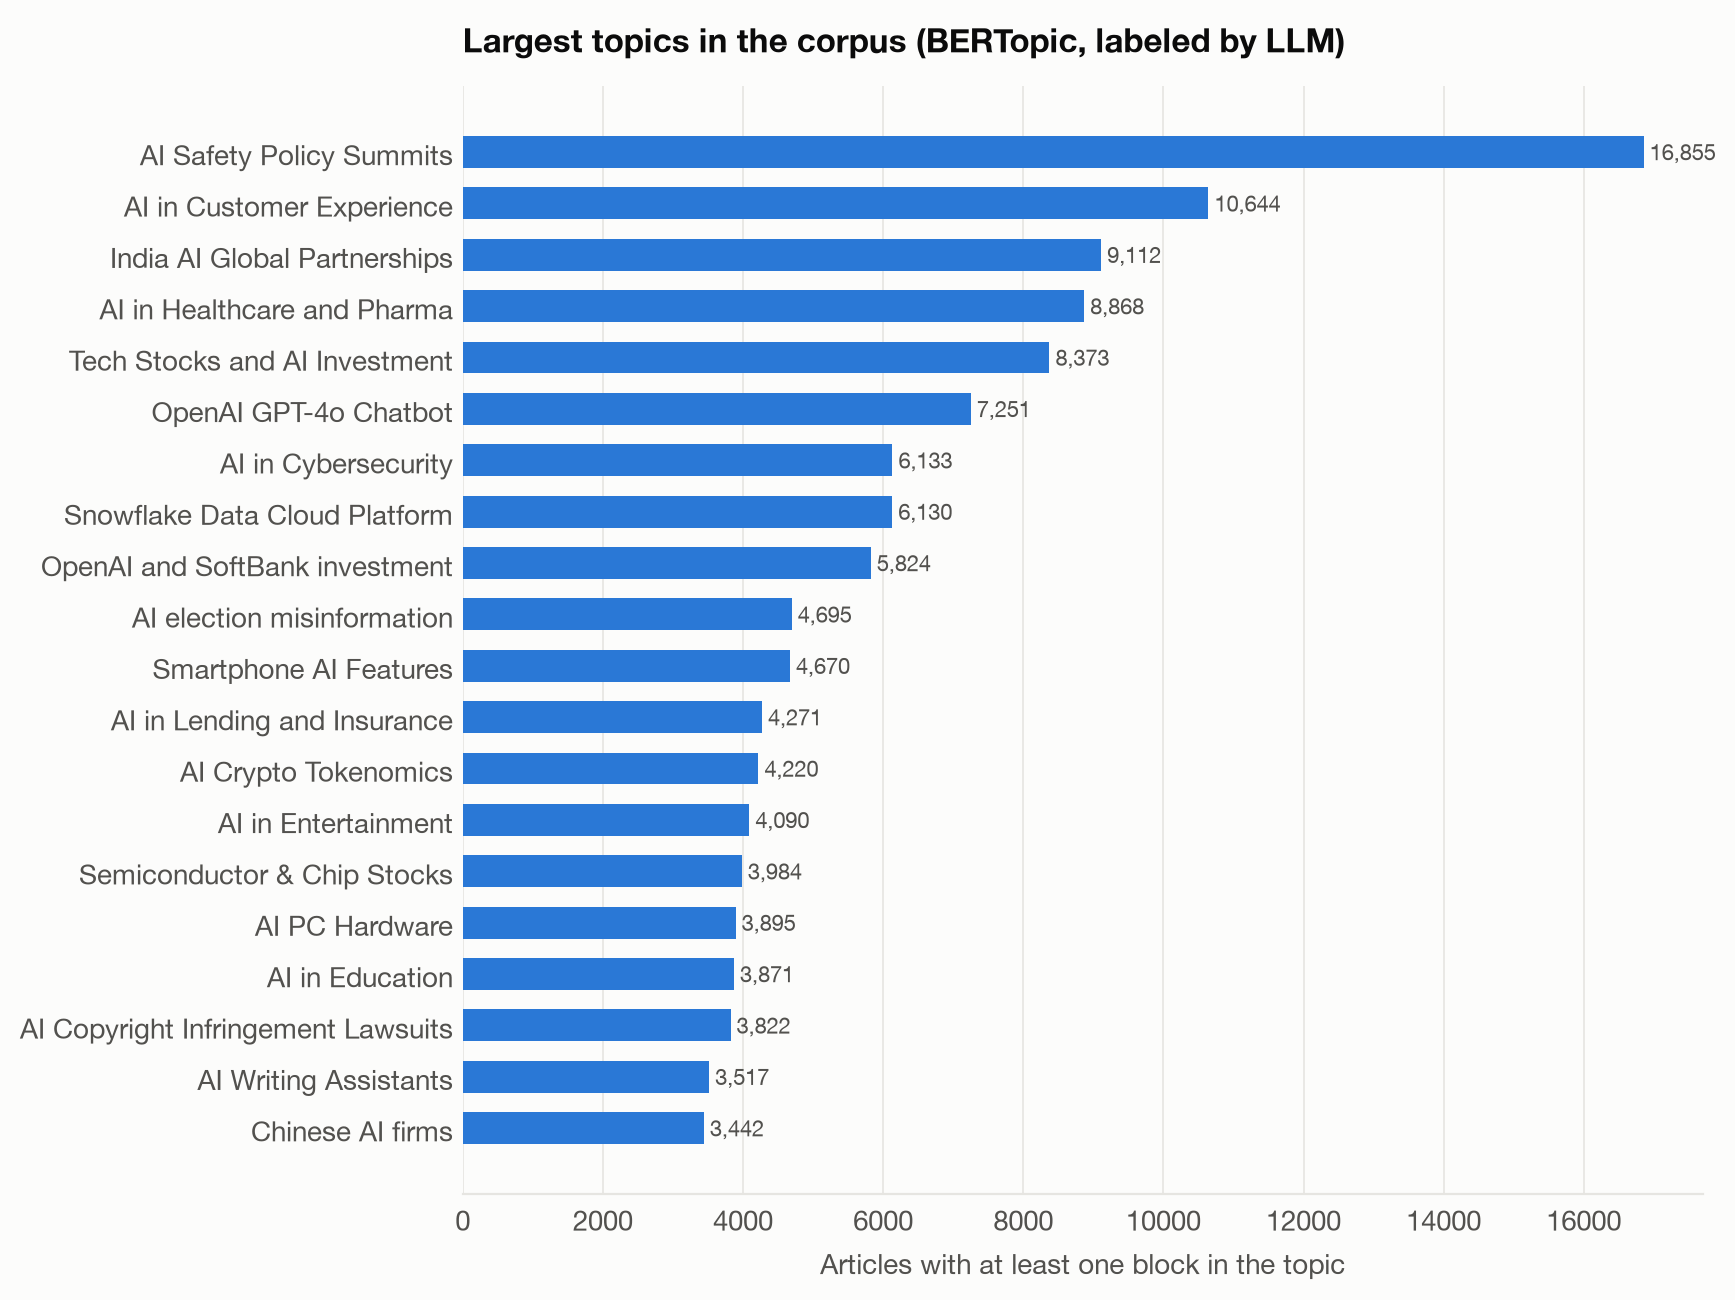

In [6]:
from IPython.display import Image
Image(filename=str(config.out("figures", "f12_topics_top.png")), width=820)

## Topics over time

Share of each quarter's articles with at least one paragraph in the topic (built in `s60_analysis.py`).

In [7]:
tq = pd.read_csv(config.out("tables", "topic_quarterly_share.csv"))
piv = tq.pivot_table(index="label", columns="quarter", values="share")
change = (piv.iloc[:, -4:].mean(axis=1) - piv.iloc[:, :3].mean(axis=1)).sort_values()
pd.concat([change.head(6), change.tail(6)]).mul(100).round(1).rename("change_pp (2022 Q1-Q3 vs last 4 quarters)").to_frame()

,change_pp (2022 Q1-Q3 vs last 4 quarters)
label,
AI in Healthcare and Pharma,-9.3
Data Science Roles and Skills,-4.0
AI Surveillance and Policing,-2.9
Automakers AI Integration,-2.3
AI ETF Market Activity,-2.1
AI PC Hardware,-1.6
Semiconductor & Chip Stocks,2.6
Smartphone AI Features,2.7
Chinese AI firms,3.0


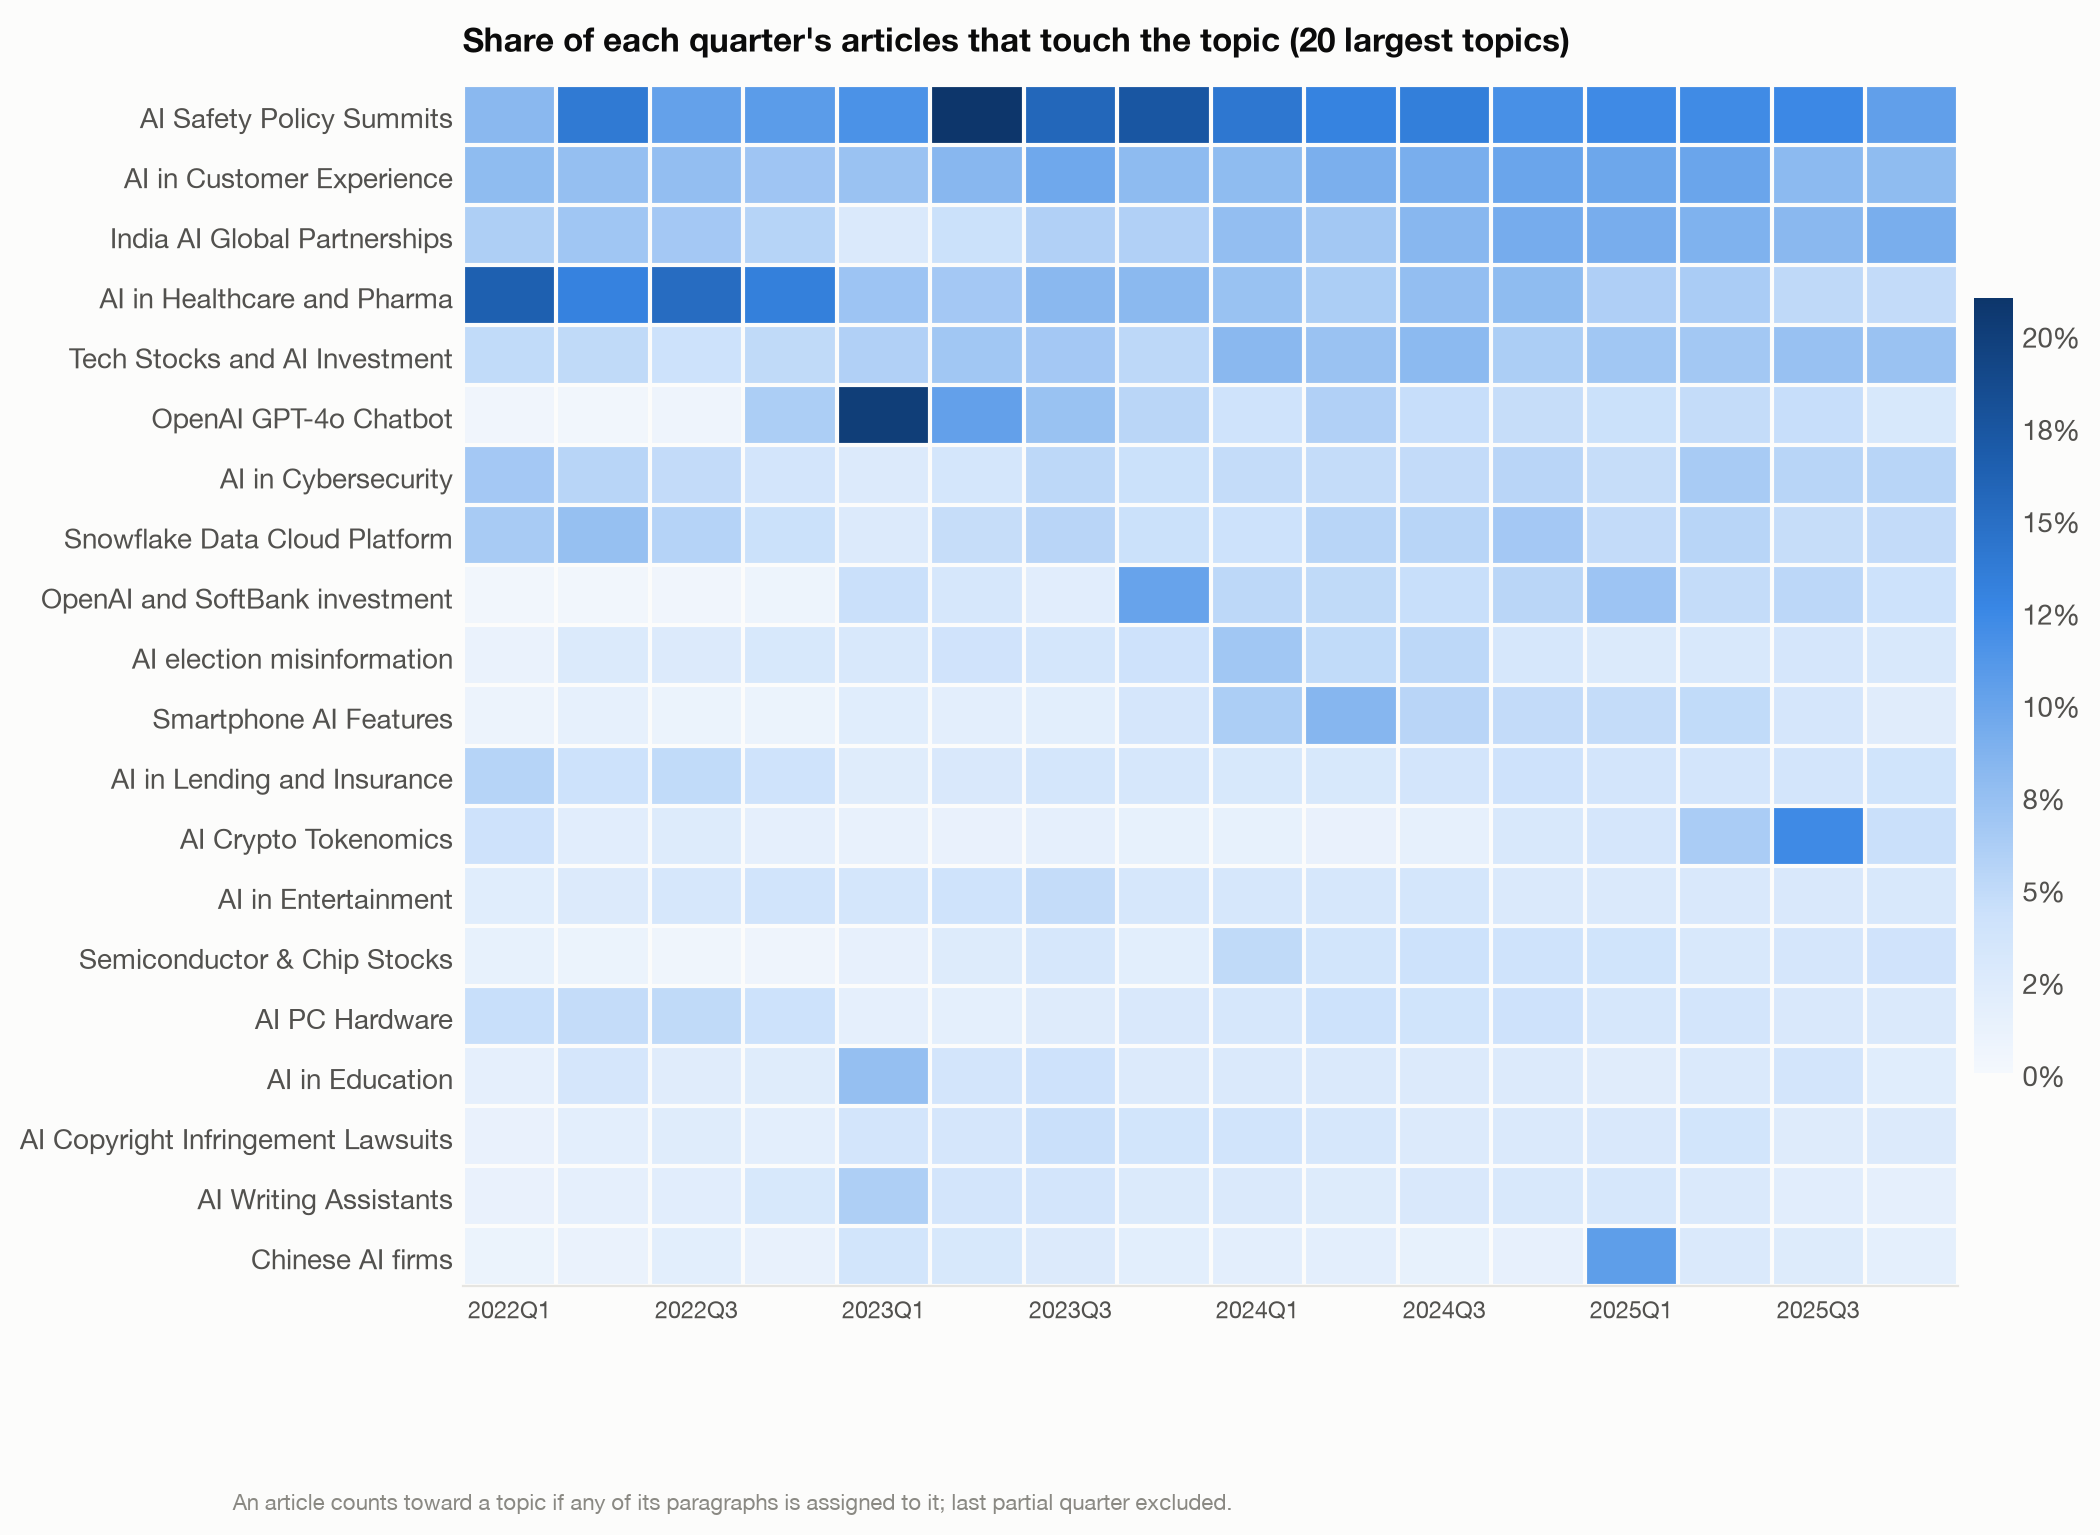

In [8]:
Image(filename=str(config.out("figures", "f14_topic_trend.png")), width=900)